A. INTRODUCTION TO SCIKIT-LEARN

In [7]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
col_names = iris.feature_names
target_names = iris.target_names
print(f"Column Name: {col_names}")
print(f"Target Name: {target_names}")
print(f"First 10 rows \n: {X[:10]}")

Column Name: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Name: ['setosa' 'versicolor' 'virginica']
First 10 rows 
: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]


B. SIMPLE LINEAR REGRESSION

In [12]:
import pandas as pd
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          

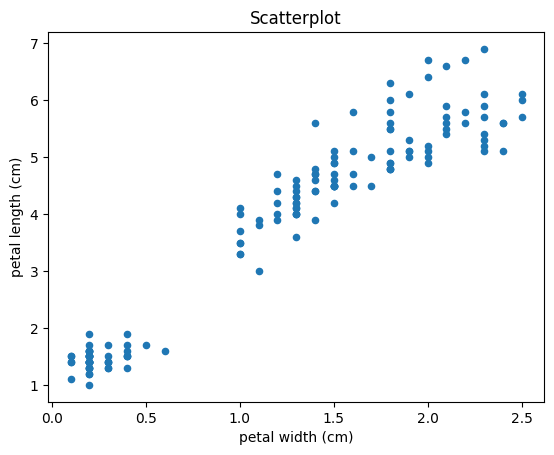

In [19]:
#EDA
df.head()
df.shape
df.plot.scatter(x='petal width (cm)', y='petal length (cm)', title='Scatterplot')
print(df.corr())
print(df.describe())

In [23]:
#Pre processing
y = df['petal width (cm)'].values.reshape(-1,1)
X = df['petal length (cm)'].values.reshape(-1,1)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(X_train)
print(y_train)

[[3.9]
 [4.9]
 [4.8]
 [5.1]
 [1.4]
 [1.5]
 [4.9]
 [1.3]
 [6.1]
 [1.4]
 [5.1]
 [1.4]
 [4.8]
 [1.5]
 [1.6]
 [5.6]
 [1.5]
 [1.5]
 [5.6]
 [4.1]
 [5.6]
 [4.7]
 [4.3]
 [4.8]
 [1.3]
 [1.2]
 [5.4]
 [5.2]
 [1. ]
 [4.8]
 [5. ]
 [1.5]
 [3.9]
 [5.4]
 [1.5]
 [1.1]
 [1.7]
 [4.1]
 [4.4]
 [4.6]
 [4. ]
 [4.6]
 [5.1]
 [1.5]
 [5.3]
 [5.6]
 [5.1]
 [1.4]
 [1.4]
 [1.9]
 [5.8]
 [5.1]
 [1.4]
 [5. ]
 [1.3]
 [4.9]
 [5.1]
 [4. ]
 [4.4]
 [4.7]
 [5.8]
 [5.6]
 [1.7]
 [4.9]
 [3.9]
 [1.4]
 [6. ]
 [5.5]
 [1.5]
 [5. ]
 [1.5]
 [1.6]
 [5.6]
 [5.9]
 [4.2]
 [4.7]
 [1.6]
 [6.9]
 [6.4]
 [3.5]
 [1.4]
 [6. ]
 [4.1]
 [4.7]
 [5.5]
 [1.4]
 [6.7]
 [5.7]
 [1.2]
 [5.9]
 [3.3]
 [3.5]
 [4.5]
 [1.4]
 [4.2]
 [1.3]
 [5.3]
 [6.7]
 [4.5]
 [1.3]
 [1.7]
 [5.1]
 [4.6]
 [1.6]
 [1.6]
 [5.8]
 [4.5]
 [1.7]
 [4.4]
 [4.5]
 [4. ]
 [6.6]
 [1.9]
 [6.3]
 [4.2]
 [4.9]
 [5.5]
 [1.6]
 [4.3]
 [5.7]]
[[1.2]
 [1.8]
 [1.8]
 [2.3]
 [0.2]
 [0.2]
 [2. ]
 [0.2]
 [2.5]
 [0.2]
 [1.8]
 [0.3]
 [1.8]
 [0.2]
 [0.2]
 [2.4]
 [0.2]
 [0.1]
 [2.4]
 [1. ]
 [1.4]
 [1.5]
 [1.3

In [25]:
#-- Train the model. --#
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
print(regressor.intercept_)
print(regressor.coef_)

[-0.35778101]
[[0.41539774]]


In [26]:
#-- Prediction. --#
score = regressor.predict([[7.5]])
print(score)

[[2.75770203]]


In [27]:
def calc(slope, intercept, value):
  return slope*value + intercept

In [29]:
score = calc(regressor.coef_, regressor.intercept_, 7.5)
print(score)

[[2.75770203]]


In [30]:
y_pred = regressor.predict(X_test)
df_pred = pd.DataFrame({'Actual': y_test.squeeze(), 'Predicted': y_pred.squeeze()})
print(df_pred)

    Actual  Predicted
0      0.1   0.265316
1      2.3   2.176145
2      1.3   1.303810
3      1.1   0.888412
4      2.0   1.802287
5      1.3   1.137651
6      1.1   1.220730
7      0.1   0.223776
8      1.0   1.013032
9      1.5   1.719208
10     0.2   0.223776
11     0.4   0.265316
12     0.2   0.182236
13     0.3   0.223776
14     0.2   0.265316
15     1.5   1.511509
16     1.4   1.469969
17     0.2   0.306855
18     1.3   1.303810
19     1.9   2.176145
20     1.2   1.386889
21     1.5   1.511509
22     0.2   0.265316
23     1.5   1.511509
24     2.5   2.009986
25     1.5   1.511509
26     1.4   1.594588
27     0.3   0.182236
28     1.5   1.760747
29     1.0   1.179191


In [31]:
#-- Evaluation the model. --#
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mae)
print(mse)
print(rmse)

0.12188212126956044
0.02614563386251435
0.1616961157929106


C. MULTIPLE LINEAR REGRESSION

In [33]:
import pandas as pd
from sklearn import linear_model
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [34]:
y = df['petal width (cm)']
X = df[['petal length (cm)', 'sepal length (cm)']]

In [35]:
regr = linear_model.LinearRegression()
regr.fit(X, y)
print(regr.coef_)

[ 0.44937611 -0.08221782]


In [37]:
pred = regr.predict([[7.2,6]])
print(pred)

[2.73320513]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [38]:
def calc(slope1, slope2, intercept, x1, x2):
  return slope1*x1 + intercept + slope2*x2

In [39]:
fpred = calc(regr.coef_[0], regr.coef_[1], regr.intercept_, 7.2, 6)
print(fpred)

2.7332051290284105
